<a href="https://colab.research.google.com/github/kspohn903/Google_Drive_Repository/blob/main/MegaMillionsExtractionAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# #PACKAGE IMPORTS/DOWNLOADS/FETCH COMMANDS FOR ENVIRONMENT

# !pip install -q timestring
# !pip install -q datetime
# !pip install -q data
# !pip install -q api-client # Alternate data collection protocols...
# !pip install -q requests_html # Web scraper packages
# !pip install -q bs4 # unneeded if you have a source of api/ data to feed in... else web scrape.
# !pip install -q urllib3 # making sure that OSI L6 stuff can read in surface html and parse web documentation/ documents
# !pip install -q nltk # data processing, sentiment analysis
# !pip install -q pandas # data frames, reading in data, blah...
# !pip install -q numpy # same as scipy. Manipulating tensor metrics, learning, adapting, etc.
# !pip install -q imgaug # Necessary if reading in specific google colab/ tensorflow,
# !pip install -q folium # usually used with image classifiers
# !pip install -q datascience # tensorflow of choice... manipulating for regressional analytics
# !pip install -q scipy
# # !pip install -q google-cloud
# !pip install -q rauth
# !pip install -q tensorflow
# !pip install -q statistics

# # !pip install --upgrade numpy # Alternative Updater to numpy...
# If not Tensorflow or conflicts in package resolution, then this one...

# ARE YOU ON THE TRAIN??? ... THEN GET ON THE TRAIN!!! Edwarrrrrd!!!!
# File reading likeness... as STRING_IO.(parserToken)

from google.colab import drive, files, auth
drive.mount('/content/drive', force_remount=True) # mounted / forcibly-remounted


Mounted at /content/drive


In [ ]:
import pandas as pd, numpy as np, sys

# # dateutil, secrets act as secondary date parser iff datetime fails or threadback issues of parsing dates...
# # optional args/ imports: ----------------------------------------------------
# import dateutil, secrets, bs4 as soup, urllib3, gzip, tenacity

#-------------------------------------------------------------------------------
import json, requests, csv, traceback as tb, seaborn as sns, scipy as sci
import matplotlib.pyplot as plt, math, gzip, os, io, re, matplotlib.pylab as pl
import matplotlib.transforms as mt, datetime, time, gc

from datetime import timedelta
# from apiclient import (APIClient, paginated, exceptions, retry_request,
#                HeaderAuthentication, JsonResponseHandler, JsonRequestFormatter, endpoint)

import sklearn
# from apiclient.retrying import retry_if_api_request_error
from matplotlib.transforms import offset_copy
from google.colab import files # Stealing/ Uploading/ Downloading to RAM files from my drive...
from sklearn.linear_model import LinearRegression, LogisticRegression
from io import StringIO

from sklearn import datasets, linear_model, svm # linear_model.(LinearRegression,LogisticRegression)
# Preferential Treatment to LogisticRegression, RidgeRegression (aka KNN-LogRegression)
from keras.models import Sequential, Model
from keras.layers import Dense, LSTM
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from pandas import Series
import statistics

# # File reading, analytics, dataframe manipulation en masse, datetime checks, garbage thread collection RAM/ NVRAM
# # Regex checking, files collected (requests/ urllib3), sys for filepath oauth checks... file dumps/reading

# # error thread checking, graphical displays, data analytics, plotting s***, you know
# # Everything here is super kosher...
# from bs4 import BeautifulSoup as bs
from matplotlib.font_manager import FontProperties


In [ ]:
# Derive_STATS_FILES.py
try:
    # Derive Mega Millions Numerical String Data of Winners from
    today = (datetime.datetime.now() - timedelta(hours=6) ) # Current day: e.g. (MM-DD-YYYY = 06-11-2021)
    print(f"today: {today}")
    today = datetime.datetime.now() # Current day: e.g. (MM-DD-YYYY = 06-11-2021)

    endMsg = input("What day are you asking to go up to? (e.g. 03/19/2021, 03/7/2022); Format: MM/DD/YYYY ")
    endInput = endMsg.strip().replace("-_","/").split("/")
    endInput = [int(el) for el in endInput]
    endYr = int(endInput[2])

    while (endInput[0] not in [i for i in range(1,13,1)]) or (
           endInput[1] not in [i for i in range(1,32,1)]) or (
           endInput[2] not in [yr for yr in range(endYr, today.year + 1, 1)]) or (
           re.match("/[(\d{1-2})(-/)(\d{1-2})(-/)(\d{2,4})]/g", endMsg) ):

          endMsg = input("What day are you asking to go up to? (e.g. 03/7/2022); Format: MM/DD/YYYY ")
          endInput = endMsg.strip().replace("-","/").split("/")
          endInput = [int(el) for el in endInput]
          endYr = int(endInput[2])

    endYr = int(endInput[2])
    print(f"Intended last day for data of Mega Millions is {endMsg}, and endYear is {endYr}...\n")

    endDay = (datetime.datetime(year = endInput[2], month = endInput[0], day = endInput[1]))

    beginMsg = input("What day are you starting? (e.g. 1/1/2020, 10/31/2017); Format: MM/DD/YYYY ")
    beginInput = beginMsg.strip().replace("-","/").split("/")
    beginInput = [int(el) for el in beginInput]
    startYr = int(beginInput[2])

    while beginInput not in [[10,31,2017],[1,2,2018],[1,1,2019],[1,3,2020],[1,1,2021],[1,4,2022]] or (
          beginInput[0] not in [i for i in range(1,13,1)]) or (
          beginInput[1] not in [i for i in range(1,32,1)]) or (
          beginInput[2] not in [yr for yr in range(startYr, today.year + 1, 1)]) or (
          re.match("/[(\d{1-2})(-/)(\d{1-2})(-/)(\d{2-4})]/g", beginMsg) ):

          beginMsg = input("What day are you starting? (e.g. 1/1/2020, 12/31/2019, 10/31/2017); Format: MM/DD/YYYY ")
          beginInput = beginMsg.strip().replace("-","/").split("/")
          beginInput = [int(el) for el in beginInput]
          startYr = int(beginInput[2])

    firstDay = (datetime.datetime(year = beginInput[2], month = beginInput[0], day = beginInput[1]))
    print(f"firstDay is {firstDay}\n")

    imgDirectories = [f"drive/Graphical Data Analysis & Analytics Projects/Mega Millions/{i}" for i in range(startYr, endYr + 1, 1)]
    csvDirectories = [f"drive/CSV_Files/Mega Millions/{i}" for i in range(startYr, endYr + 1,1)]

    for imgDir in imgDirectories: #Forcing deletion of prior data files of intended subdirectories
        if os.path.exists(f"{imgDir}/"):
           for fileName in os.walk(f"{imgDir}"):
               print(f"\tAttempting to delete {imgDir}/{fileName}...")
               os.rmdir(f"{imgDir}/{fileName}") # Recursively and forcefully removing data from file directories...
        print(f"Deletion/Recreation of imgDir='{imgDir}/' successful.")

    for csvDir in csvDirectories:
        if os.path.exists(f"{csvDir}/"):
           for fileName in os.walk(f"{csvDir}"):
               print(f"\tAttempting to delete {imgDir}/{fileName}...")
               os.rmdir(f"{csvDir}/{fileName}") # Recursively and forcefully removing data from file directories...
        print(f"Deletion/Recreation of csvDir='{csvDir}/' successful.")

    # Oct 31, 2017; 2020 data is set to Dec, 31, 2019 in the above format
    #
    # Beyond this point back, number winning schemas are inconsistent and
    # remain pairwise within certain time periods/ intervals

    fDayString = firstDay.strftime("%m %d %Y")
    fDayString = fDayString.replace(" ","_")

    endString = endDay.strftime("%m %d %Y")
    endString = endString.replace(" ", "_")

    print(f"fDayString: {fDayString}\nendString: {endString}\n")

    # Modify to closest Tuesday/Thursday, based on bi-weekly draws approx. Midnight that day...
    yearA = firstDay.year # MM/DD/YYYY
    print(f"yearA is {yearA}\n")

    # !!!! ASSUMING U KNOW NEW LINES OF DATA FOR Mega Millions/ POWERBALL WINS, then append
    # In theory, one could use io, os remote linux commands to force change, then reassign home directory using os.chdirName(f"{superDirName}")
    # ... I'm not doing that because it requires continually using try...except...finally loops to redirect back to base home directory name ... os.subprocess["cd" f"{superDirName}"]
    # where currDirName logged as a var to change back at end using either command subprocess exec @ runtime ...
    # Read in excel file f"{superDirName}/{MegaBall_Schema.xlsx}"
    # Append newest Number Ball Set Scraped from website
    # from openpyxl import Workbook, load_workbook
    # gameType = "Mega Millions" # ["PowerBall", "Mega Millions", ...]
    # superDirName = f"/content/drive/MyDrive/CSV_Files/{gameType}/"
    # schemaXLSX_FileName = "{}{}_Schema.xlsx".format(superDirName, gameType)

    # wb = load_workbook(schemaXLSX_FileName)
    # chosenWS = wb[beginYr] # schema oriented with beginYr...
    # missedValues = pd.read_csv("{}{}_Whatd_I_Miss_as_of_{}.csv".format(superDirName, gameType, endString),header=0)
    # header = list(missedValues.columns.values)[1:-2]
    # print(f"header = {header}\n")
    # for row in newMegaBall_Rows:
    #     for i in range(1,len(missedValues[header[0]].values)+1, 1):
    #         [Ball1,Ball2,Ball3,Ball4,Ball5, megaBall, mult] = [missedValues[header[k]].values for k in range(0, len(header), 1)]
    #         chosenWS.append(f"{Ball1}",f"{Ball2}",f"{Ball3}",f"{Ball4}",f"{Ball5}", f"{megaBall}",f"{mult}",
    #                         f"{Ball1} {Ball2} {Ball3} {Ball4} {Ball5} {megaBall} {mult}x")
    # print(f"Before saving, workbook as {schemaXLSX_FileName}, attempting to save current worksheet, {beginYr}\n, as a csv file... {superDirName}{gameType}_{yearA}_as_of_{endString}.xlsx")
    # with open(f"{superDirName}{gameType}_{yearA}_as_of_{endString}.xlsx.csv", 'w+', newline="") as schemaFile:  # for python 3
    # c = csv.writer(schemaFile)
    # for r in chosenWS.rows:
    #     c.writerow([cell.value for cell in r])
    # c.close()
    # wb.save(schemaXLSX_FileName)
    !wget "https://nclottery.com/mega-millions-download" f"{superDirName}MegaBall_Schema_{yearA}_as_of_{endString}.csv"
    superDirName = 'drive/MyDrive/CSV_Files/Mega Millions/'
    filePathName = '{}MegaBall_Schema_{}_as_of_{}.csv'.format(superDirName, yearA, endString)

    # Manually download from the NY State / NYC municipality dataset. Then,
    # Append any subsequent data from future dates... append all 5 data tables up to speed ...
    # Then download it...
    # Now from Excel Google Sheets, read in data as normal

    #  print(f"Before reading in from file path, \
    #  Steve-Bot is testing file read in from os, and validity of dataframe...\n")

    dfMegaMillions = pd.read_csv(filePathName,header=0)
    print("dfMegaMillions is successfully being read in...\n")

    print("---------- The column headers ------------\n")
    headerColumns = list(dfMegaMillions.columns.values)
    print(f"Header Columns: {headerColumns}\n")

    drawingDate = dfMegaMillions[headerColumns[0]].values
    firstNum = dfMegaMillions[headerColumns[1]].values
    secondNum = dfMegaMillions[headerColumns[2]].values
    thirdNum = dfMegaMillions[headerColumns[3]].values
    fourthNum = dfMegaMillions[headerColumns[4]].values
    fifthNum = dfMegaMillions[headerColumns[5]].values
    megaBall = dfMegaMillions[headerColumns[6]].values
    megaplier = dfMegaMillions[headerColumns[7]].values
    jackpot = dfMegaMillions[headerColumns[-1]].values

    lenCheck = [len(drawingDate) == el for el in [len(firstNum), len(secondNum),
                                                 len(thirdNum), len(fourthNum),
                                                 len(fifthNum), len(megaBall), len(jackpot)] ]

    # print(f"arrLenCheck:{lenCheck}, allSameSizeVectors: {False not in lenCheck}\n")

    #  data = [drawingDate,firstNumber, secondNumber, thirdNumber,
    #          fourthNumber, fifthNumber, megaBall, megaplier ]

    megaHeadersJSON = [ "First_Number", "Second_Number", "Third_Number",
                        "Fourth_Number", "Fifth_Number", "Mega_Ball", "Megaplier", "Jackpot" ]

    #  print(f"DrawingDate:\n{drawingDate}\nFirstNumber:\n{firstNum}\n")
    #  print(f"SecondNumber:\n{secondNum}\nThirdNumber:\n{thirdNum}\n")
    #  print(f"FourthNumber:\n{fourthNum}\nFifthNumber:\n{fifthNum}\n")
    #  print(f"MegaBall:\n{megaBall}\nMegaplier:\n{megaplier}\nJackpot:\n{jackpot}\n")

    currentJackPot = jackpot[-1]
    print(f"Current Jackpot is {currentJackPot}...\n")

    jsonFreq = { # By definition first 5 1-70, last one 1-25
    1 : {"{}".format(i): 0 for i in range(1,71,1)}, # 1-70; Ball 1
    2 : {"{}".format(i): 0 for i in range(1,71,1)}, # 1-70; Ball 2
    3 : {"{}".format(i): 0 for i in range(1,71,1)},  # 1-70; Ball 3
    4 : {"{}".format(i): 0 for i in range(1,71,1)},  # 1-70; Ball 4
    5 : {"{}".format(i): 0 for i in range(1,71,1)}, # 1-70; Ball 5
    6 : {"{}".format(i): 0 for i in range(1,26,1)}, # 1-25; Mega Ball
    } # append all elements into each respective json

    # print(f"Before populating by frequencies:\n{jsonFreq}\n")

    for i in range(0, len(firstNum), 1): #dnc about the megaplier, jackpot for this part...
        jsonFreq[1]["{}".format(firstNum[i])] += 1
        jsonFreq[2]["{}".format(secondNum[i])] += 1
        jsonFreq[3]["{}".format(thirdNum[i])] += 1
        jsonFreq[4]["{}".format(fourthNum[i])] += 1
        jsonFreq[5]["{}".format(fifthNum[i])] += 1
        jsonFreq[6]["{}".format(megaBall[i])] += 1

        #  print(f"Populating Frequency Iteration no. {i+1}: (")
        #  print(f"json1={jsonFreq[1]},json2={jsonFreq[2]},json3={jsonFreq[3]}", end=',')
        # print(f"json4={jsonFreq[4]}, json5={jsonFreq[5]}, json6={jsonFreq[6]})", end = "\n")
    # print(f"After: {jsonFreq}\n")

    #  t1, t2, t3, t4, t5, t6 = 0, 0, 0, 0, 0, 0
    k1 = list(jsonFreq[1].keys())
    k2 = list(jsonFreq[2].keys())
    k3 = list(jsonFreq[3].keys())
    k4 = list(jsonFreq[4].keys())
    k5 = list(jsonFreq[5].keys())
    k6 = list(jsonFreq[6].keys())
    #  print(f"k1: {k1}\nk2: {k2}\nk3: {k3}\nk4: {k4}\nk5: {k5}\nk6: {k6}\n")

    v1 = list(jsonFreq[1].values()) # Frequencies of 1-70 for Nums. 1-5
    v2 = list(jsonFreq[2].values())
    v3 = list(jsonFreq[3].values())
    v4 = list(jsonFreq[4].values())
    v5 = list(jsonFreq[5].values())
    v6 = list(jsonFreq[6].values()) # MegaBall Frequencies 1-25
    #  print(f"v1: {v1}\nv2: {v2}\nv3: {v3}\nv4: {v4}\nv5: {v5}\nv6: {v6}\n")

    vTot = [int(el) for el in v1]
    t1, t2, t3, t4, t5, t6 = 0, 0, 0, 0, 0, 0
    for i in range(0,len(v1), 1):
       e1 = int(vTot[i])
       e2 = int(v2[i])
       e3 = int(v3[i])
       e4 = int(v4[i])
       e5 = int(v5[i])

       #  print(f"(e1={e1}, e2={e2}, e3={e3}, e4={e4}, e5={e5})\n")
       sumFreq = int (e2+e3+e4+e5)

       #  print(f"Prior to appending sumFreq: (lTot: {int(vTot[i])}, sumFreq:{sumFreq})\n")
       t1 += int(v1[i])
       t2 += int(v2[i])
       t3 += int(v3[i])
       t4 += int(v4[i])
       t5 += int(v5[i])
       vTot[i] += int(sumFreq)

       #  print(f"Total Frequency for Digit No.{i+1} (for Balls 1-5), is {int(vTot[i])}.\n")
       #  print(f"Stats for iteration No. = {i+1}: (t1={t1}, t2={t2}, t3={t3}, t4={t4}, t5={t5})\n")

    # print(f"Final Stats: (t1:{t1}, t2:{t2}, t3:{t3}, t4:{t4}, t5:{t5})\n")
    print(f"After total appendation, vTot: {vTot}\n")

    maxNoDraws = t1
    # print(f"maxNoDraws: {maxNoDraws}\n")

    jsonFreq[7] = {"{}".format(i+1): int(vTot[i]) for i in range(0,len(vTot),1)}
    # print(f"Checking jsonFreq[7] patch: {jsonFreq[7]}\n")
    df_1_5 = pd.DataFrame(data= {
                                  "Ball 1": jsonFreq[1],
                                  "Ball 2": jsonFreq[2],
                                  "Ball 3": jsonFreq[3],
                                  "Ball 4": jsonFreq[4],
                                  "Ball 5": jsonFreq[5],
                                  "Total": jsonFreq[7]
                                } )
    #  # weighted stat. avg. of total draws, i.e. max. no draws from dt A to dt B (today).
    df_1_5["P(Ball 1)"] = round(df_1_5["Ball 1"]/maxNoDraws, 6)
    df_1_5["P(Ball 2)"] = round(df_1_5["Ball 2"]/maxNoDraws, 6)
    df_1_5["P(Ball 3)"] = round(df_1_5["Ball 3"]/maxNoDraws, 6)
    df_1_5["P(Ball 4)"] = round(df_1_5["Ball 4"]/maxNoDraws, 6)
    df_1_5["P(Ball 5)"] = round(df_1_5["Ball 5"]/maxNoDraws, 6)
    df_1_5["P(Total)"] = round(df_1_5["Total"]/maxNoDraws, 6)

    df_1_5.sort_values(by=['P(Total)','Total'], inplace=True, ascending=False)
    #  print(f"{df_1_5['P(Total)']}\n{df_1_5['P(Ball 1)']}\n{df_1_5['P(Ball 2)']}\n{df_1_5['P(Ball 3)']}\n{df_1_5['P(Ball 4)']}\n{df_1_5['P(Ball 5)']}\n")

    b_1_5_stats = {}
    b_1_5 =  [firstNum, secondNum, thirdNum, fourthNum, fifthNum, df_1_5["Total"].values,
              df_1_5["P(Ball 1)"].values, df_1_5["P(Ball 2)"].values, df_1_5["P(Ball 3)"].values,
              df_1_5["P(Ball 4)"].values, df_1_5["P(Ball 5)"].values, df_1_5["P(Total)"].values ]
    ballNames = ["Ball 1", "Ball 2", "Ball 3", "Ball 4", "Ball 5", "Ball Total",
                 "P(Ball 1)", "P(Ball 2)", "P(Ball 3)","P(Ball 4)", "P(Ball 5)", "P(Total)"]
    for i in range(0,len(b_1_5), 1):
        ball = b_1_5[i]
        b_1_5_stats[f"{ballNames[i]}"] = {
                              "Mean": np.mean(ball),
                              "Standard Deviation": np.std(ball),
                              "Variance": np.var(ball),
                              "Median": np.median(ball),
                              # "Mode": statistics.multimode(ball),
                              "Minimum": np.min(ball),
                              "Maximum": np.max(ball),
                              "Sample Variance": (np.var(ball)* (ball.size/((ball.size - 1)*1.0))),
                              "Sample Skewness": (sci.stats.skew(ball)),
                              "Sample Fisher Kurtosis": (sci.stats.kurtosis(ball)), # fisher = True
                              "Sample Kurtosis Bias Normalized": (sci.stats.kurtosis(ball, fisher=False)), # Fisher = False
    }
    df_b1_5_Stats_to_Date = pd.DataFrame(data=b_1_5_stats)
    df_b1_5_Stats_to_Date.head()
    df_b1_5_Stats_to_Date.to_csv(f"{superDirName}{yearA}/Proper_Mega_Millions_Ball5_Stats_{yearA}_as_of_{endString}.csv", index = True)

    df_6 = pd.DataFrame(data={"MegaBall": jsonFreq[6] })
    df_6["P(MegaBall)"] = round(df_6["MegaBall"]/maxNoDraws, 6)
    df_6.sort_values(by=['P(MegaBall)','MegaBall'], inplace=True, ascending=False)
    #  print(f"df_1_5:\n{df_1_5}\ndf_6:\n{df_6}\nProb_Total:\n{df_1_5['Prob_Total']}\n")

    mb_stats = {}
    mbHeader = ["MegaBall", "P(MegaBall)"]
    mb = [megaBall, df_6["P(MegaBall)"].values]
    for i in range(0,len(mbHeader),1):
        mB = mb[i]
        mb_stats[f"{mbHeader[i]}"] = {
                              "Mean": np.mean(mB),
                              "Standard Deviation": np.std(mB),
                              "Variance": np.var(mB),
                              "Median": np.median(mB),
                              # "Mode": statistics.multimode(mB),
                              "Minimum": np.min(mB),
                              "Maximum": np.max(mB),
                              "Sample Variance": (np.var(mB)* (mB.size/((mB.size - 1)*1.0))),
                              "Sample Skewness": (sci.stats.skew(mB)),
                              "Sample Fisher Kurtosis": (sci.stats.kurtosis(mB)), # fisher = True
                              "Sample Kurtosis Bias Normalized": (sci.stats.kurtosis(mB, fisher=False)), # fisher = False
    }
    df_mb_Stats_to_Date = pd.DataFrame(data=mb_stats)
    df_mb_Stats_to_Date.head()
    df_mb_Stats_to_Date.to_csv(f"{superDirName}{yearA}/Proper_Mega_Millions_MegaBall_Stats_{yearA}_as_of_{endString}.csv", index = True)

    df_1_5.to_csv('{}{}/Mega_Millions_Ball5_Stats_{}_as_of_{}.csv'.format(superDirName, yearA, yearA, endString), index = True) # yearNo: e.g. {2020,2021}, v. overall
    df_6.to_csv('{}{}/Mega_Millions_Mega_Ball_Stats_{}_as_of_{}.csv'.format(superDirName, yearA, yearA, endString), index=True)
    print(f"All DataFrame objects have been saved to misc. csv files for later extraction, analytics, and likelihood estimators...\nShutting down...\n")

except IOError:
       print(f"Failure to properly close/read file (IO). Please check stack trace and try again.\n")
       tb.print_exc()
except EOFError:
       print(f"Failure to properly read/parse file properly or has reached EOF.Please check stack trace and try again.\n")
       tb.print_exc()
except IndentationError:
       print(f"Failure to properly indent. Please check stack trace and try again.\n")
       tb.print_exc()
except ImportError:
       print(f"Import has failed. Please check imports and try again.\n")
       tb.print_exc()
except Exception:
       print(f"General Exception has occurred. Please check stack trace and try again.\n")
       tb.print_exc()
except:
       print(f"General Error has occurred. Please check stack trace and try again.\n")
       tb.print_exc()

today: 2022-06-12 15:48:32.174832
What day are you asking to go up to? (e.g. 03/19/2021, 03/7/2022); Format: MM/DD/YYYY 6/12/2022
Intended last day for data of Mega Millions is 6/12/2022, and endYear is 2022...

What day are you starting? (e.g. 1/1/2020, 10/31/2017); Format: MM/DD/YYYY 1/4/2022
firstDay is 2022-01-04 00:00:00

Deletion/Recreation of imgDir='drive/Graphical Data Analysis & Analytics Projects/Mega Millions/2022/' successful.
Deletion/Recreation of csvDir='drive/CSV_Files/Mega Millions/2022/' successful.
fDayString: 01_04_2022
endString: 06_12_2022

yearA is 2022

dfMegaMillions is successfully being read in...

---------- The column headers ------------

Header Columns: ['DrawingDate', 'FirstNumber', 'SecondNumber', 'ThirdNumber', 'FourthNumber', 'FifthNumber', 'MegaBall', 'Megaplier', 'NumberSet', 'Jackpot']

Current Jackpot is 226000000...

After total appendation, vTot: [1, 5, 7, 5, 3, 6, 7, 4, 3, 0, 8, 2, 2, 4, 6, 6, 3, 3, 6, 4, 5, 7, 1, 4, 2, 1, 2, 4, 3, 1, 2, 2, 3,

The Header Columns Ball5: ['Unnamed: 0' 'Ball 1' 'Ball 2' 'Ball 3' 'Ball 4' 'Ball 5' 'Total'
 'P(Ball 1)' 'P(Ball 2)' 'P(Ball 3)' 'P(Ball 4)' 'P(Ball 5)' 'P(Total)']

The Header Columns MegaBall: ['Unnamed: 0' 'MegaBall' 'P(MegaBall)']



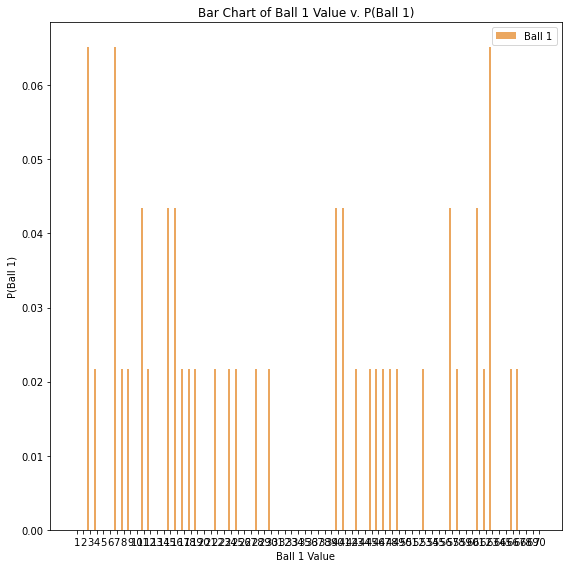

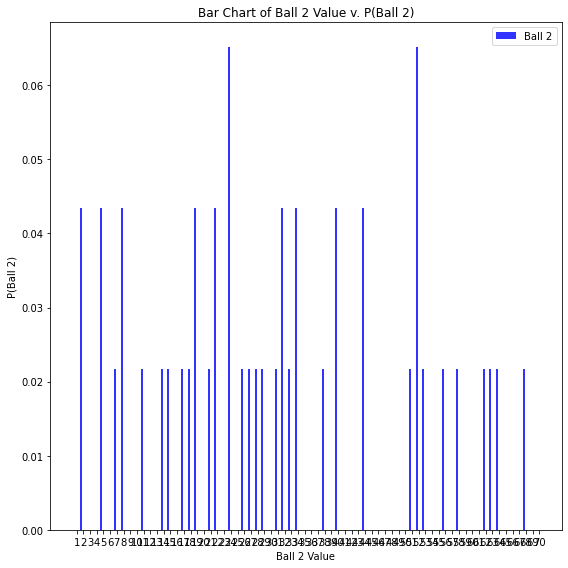

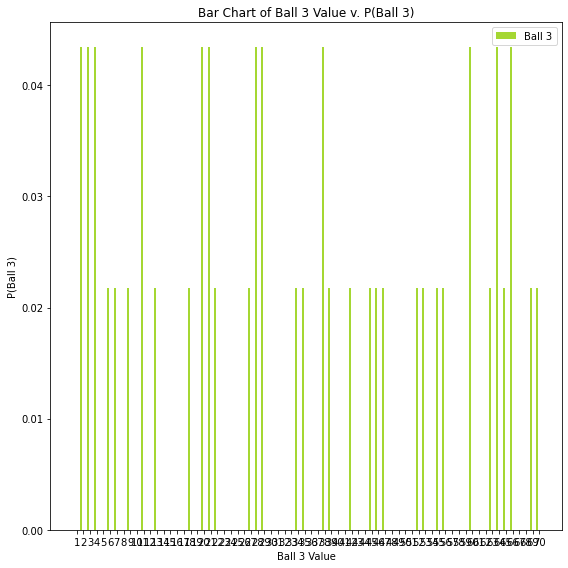

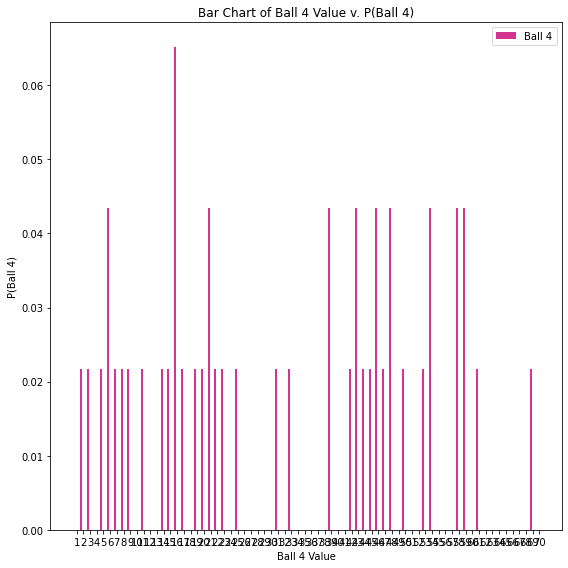

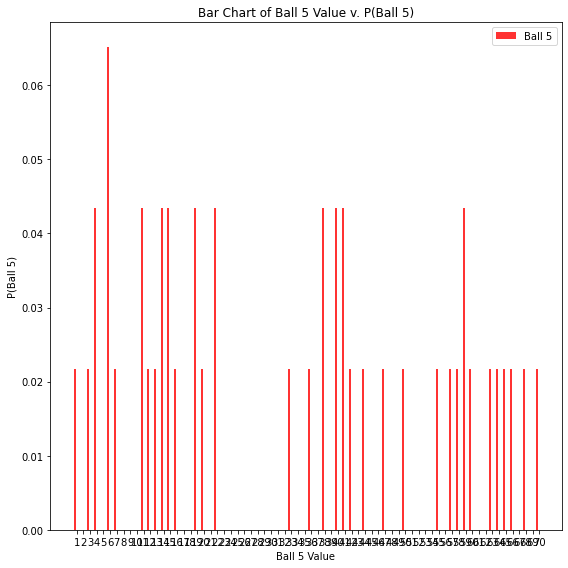

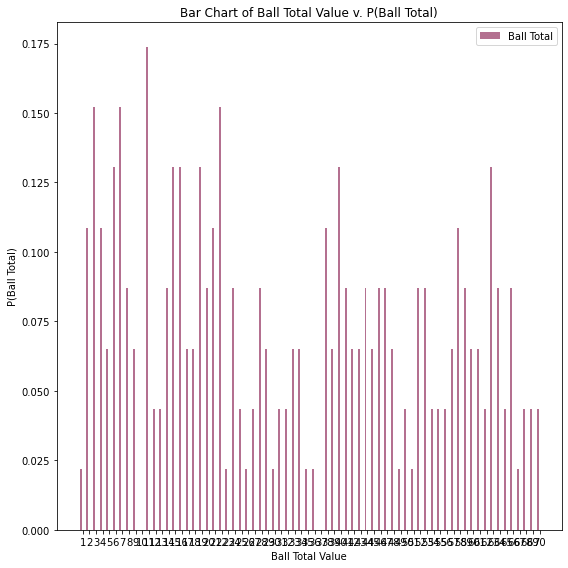

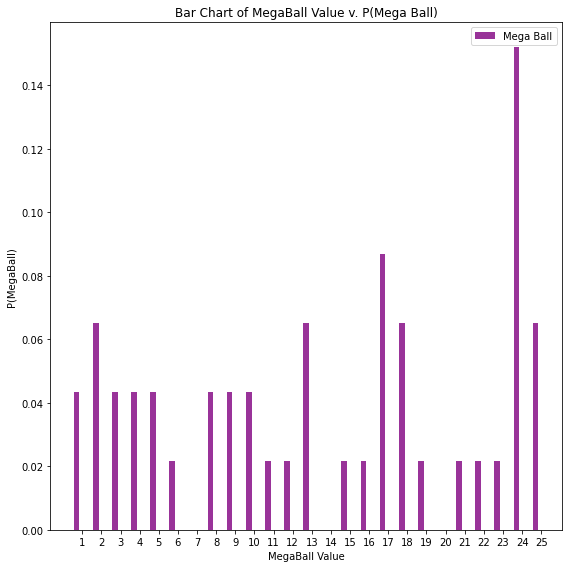

In [ ]:
# Prev. File Name: MEGAMILLIONS_Stat_Pictographic.py
# split dataset in train and testing set
import matplotlib.pyplot as plt
try:
    #yearA, beginMsg/todayStr ... No longer needed... Input already validated.

    filePathName1 = f'{superDirName}{yearA}/Mega_Millions_Ball5_Stats_{yearA}_as_of_{endString}.csv'
    filePathName2 = f'{superDirName}{yearA}/Mega_Millions_Mega_Ball_Stats_{yearA}_as_of_{endString}.csv'
    # print(f"Before reading in from file path, Steve-Bot is testing file read in from os, and validity of dataframe...\n")

    dfMegaMillions_Ball5 = pd.read_csv(filePathName1, header=0) #
    # print("dfMegaMillions_Ball5 is successfully being read in...\n")

    headerColumnsBall5 = dfMegaMillions_Ball5.columns.values
    print(f"The Header Columns Ball5: {headerColumnsBall5}\n")

    datasetBall5 = dfMegaMillions_Ball5.values
    dfMegaMillions_MegaBall = pd.read_csv(filePathName2,header=0)
    datasetMB = dfMegaMillions_MegaBall.values
    # print("dfMegaMillions_MegaBall is successfully being read in...\n")

    headerColumnsMegaBall = dfMegaMillions_MegaBall.columns.values
    print(f"The Header Columns MegaBall: {headerColumnsMegaBall}\n")

    # Values 5 Ball, megaBall: headerColumnsMegaBall[0], headerColumnsBall5[0]
    # 5 Ball: [Value, First_Number, Second_Number, Third_Number, Fourth_Number, Fifth_Number, Total,
    # Prob_Ball1, Prob_Ball2, Prob_Ball3, Prob_Ball4, Prob_Ball5, Prob_Total]
    # Mega Ball: [Ball Value, Freq_Mega_Ball, Prob_Mega_Ball]

    # Assuming values in numB5, numMB are dependent on probability of regressional predictions...
    # Where the probability of a number is treated as independent, non-categorical
    xB5 = dfMegaMillions_Ball5[headerColumnsBall5[0]] # Ball Value for B5
    xMB = dfMegaMillions_MegaBall[headerColumnsMegaBall[0]] # Ball Value for MB
    # print(f"(xB5: {xB5.values}\nxMB: {xMB.values})\n")

    yB1 = dfMegaMillions_Ball5[headerColumnsBall5[-6]] # Prob_Ball1 Column Data
    yB2 = dfMegaMillions_Ball5[headerColumnsBall5[-5]] # Prob_Ball2 ...
    yB3 = dfMegaMillions_Ball5[headerColumnsBall5[-4]] # Prob_Ball3 ...
    yB4 = dfMegaMillions_Ball5[headerColumnsBall5[-3]] # Prob_Ball4 ...
    yB5 = dfMegaMillions_Ball5[headerColumnsBall5[-2]] # Prob_Ball5 ...
    yBTot = dfMegaMillions_Ball5[headerColumnsBall5[-1]] # Prob_Total ...

    # yB = [yB1, yB2, yB3, yB4, yB5, yBTot]
    # Prob Ball_5: {Prob_Ball{i+1}, Prob_Total}

    yMB = dfMegaMillions_MegaBall[headerColumnsMegaBall[2]]
    # print(f"(yB1:{yB1.values}\nyB2:{yB2.values}\nyB3:{yB3.values}\nyB4:{yB4.values}\nyB5:{yB5.values}\nyBTot:{yBTot.values})\n")

    # Creating figure & saving relevant graphics data
    # EX: ---------------------------------------------------------------------
    # Assuming that len(x)==len(y) for datasets
    # x = [] # Ball Counts & Probabilities
    # y = [] # Yield Predicted
    #     lin_reg = LinearRegression()
    # lin_reg.fit(X,y)

# # visualising the linear regression model
# plt.scatter(X,y, color='red')
# plt.plot(X, lin_reg.predict(X),color='blue')
# plt.title("Truth or Bluff(Linear)")
# plt.xlabel('Position level')
# plt.ylabel('Salary')
# plt.show()

# # polynomial regression model
# from sklearn.preprocessing import PolynomialFeatures
# poly_reg = PolynomialFeatures(degree=2)
# X_poly = poly_reg.fit_transform(X)

# X_poly     # prints X_poly

# lin_reg2 = LinearRegression()
# lin_reg2.fit(X_poly,y)


# # visualising polynomial regression
# from sklearn.preprocessing import PolynomialFeatures
# poly_reg = PolynomialFeatures(degree=4)
# X_poly = poly_reg.fit_transform(X)
# lin_reg2 = LinearRegression()
# lin_reg2.fit(X_poly,y)

# X_grid = np.arange(min(X),max(X),0.1)
# X_grid = X_grid.reshape(len(X_grid),1)
# plt.scatter(X,y, color='red')

# plt.plot(X_grid, lin_reg2.predict(poly_reg.fit_transform(X_grid)),color='blue')

# plt.title("Truth or Bluff(Polynomial)")
# plt.xlabel('Position level')
# plt.ylabel('Salary')
# plt.show()

    nSubgroupsBall5 = 70
    nBall5 = 5
    totNoEl = 6
    bar_width = 0.30
    opacity = 0.80

    # Super Bar Chart of plots B1-B5, Ball Total
    rows, cols = 2,3
    colors = ['#e69138',"blue",'#8fce00','#c90076','red','#A14C75' ]
    label = ["Ball 1", "Ball 2", "Ball 3", "Ball 4", "Ball 5", "Ball Total"]
    yLabel = ["P(Ball 1)", "P(Ball 2)", "P(Ball 3)", "P(Ball 4)", "P(Ball 5)", "P(Ball Total)"]
    setTitle = label
    # weird-orange,blue, lime-green, hard-magenta, red, velvet/ salmon-pink

    graphDirName = 'drive/MyDrive/Graphical Data Analysis & Analytics Projects/Mega Millions/'
    yBall5_JSON = { 1: yB1, 2: yB2, 3: yB3, 4:yB4, 5:yB5, 6:yBTot }
    for r in range(0, rows, 1):
        for c in range(0, cols, 1):
             fig1, ax1 = plt.subplots(figsize=(8,8))
             count = 3*r+c
             bChartB5 = plt.bar(xB5, yBall5_JSON[count+1], bar_width, alpha=opacity, color=colors[count], label=label[count])
             plt.xlabel(f"{label[count]} Value")
             plt.ylabel(yLabel[count])
             plt.title('Bar Chart of {} Value v. {}'.format(label[count], yLabel[count]) )
             # print(f"Testing if tuple arr concatonator works for str bar chart grouped by stat frequency ***BEFORE***...\n")
             plt.xticks(xB5 + bar_width, tuple([str(ball) for ball in xB5]) )
             # print(f"Testing if tuple arr concatonator works for str bar chart grouped by stat frequency ***AFTER***...\n")
             plt.legend()
             plt.tight_layout()
             plt.savefig('{}{}/MegaMillions_{}_BarChartPlot_{}_{}.png'.format(graphDirName, yearA,
                 label[count], yearA, datetime.datetime.now().strftime("%Y %m %d").replace(" ","-") ) )
             plt.show()

    fig2, ax2 = plt.subplots(figsize=(8,8))
    bChartMB = plt.bar(xMB, yMB, bar_width, alpha=opacity, color='purple', label='Mega Ball')
    plt.xlabel('MegaBall Value')
    plt.ylabel('P(MegaBall)')
    plt.title('Bar Chart of MegaBall Value v. P(Mega Ball)')
    # print(f"Testing if tuple arr concatonator works for str bar chart grouped by stat frequency ***BEFORE***...\n")
    plt.xticks(xMB + bar_width, tuple([str(ball) for ball in xMB]) )
    # print(f"Testing if tuple arr concatonator works for str bar chart grouped by stat frequency ***AFTER***...\n")
    plt.legend()
    plt.tight_layout()
    plt.savefig('{}{}/MegaMillions_MegaBall_BarChartPlot_{}_{}.png'.format(
        graphDirName, yearA, yearA, datetime.datetime.now().strftime("%Y %m %d").replace(" ","-") ) )
    plt.show()

    # regB1=LinearRegression()
    # regB1.fit(numB5,p1B5)
    # y_pre = reg.predict(X_test)

    ### Intended for Regression _Prediction, either RidgeRegression using lineardense
        # as matrix fodder data, and trainsets for linear predictors,
        # based on KNN's, but I'm not skilled enough to use a KNN of that
        # regression predictor form... Not competent enough, yet.

except IOError:
       print(f"Failure to properly close/read file (IO). Please check stack trace and try again.\n")
       tb.print_exc()
except EOFError:
       print(f"Failure to properly read/parse file properly or has reached EOF.Please check stack trace and try again.\n")
       tb.print_exc()
except IndentationError:
       print(f"Failure to properly indent. Please check stack trace and try again.\n")
       tb.print_exc()
except ImportError:
       print(f"Import has failed. Please check imports and try again.\n")
       tb.print_exc()
except Exception:
       print(f"General Exception has occurred. Please check stack trace and try again.\n")
       tb.print_exc()
except:
       print(f"General Error has occurred. Please check stack trace and try again.\n")
       tb.print_exc()


In [ ]:
# Create ALL MEGA_MILLIONS
# yearA = 2017
superMMDirName = "drive/MyDrive/CSV_Files/Mega Millions/{}/".format(yearA)
B5_FilePath = "{}Mega_Millions_Ball5_Stats_{}_as_of_{}.csv".format(superMMDirName,yearA, endString)
MB_FilePath = "{}Mega_Millions_Mega_Ball_Stats_{}_as_of_{}.csv".format(superMMDirName,yearA, endString)
print(f"FilePaths: \nB5: {B5_FilePath}\nMB: {MB_FilePath}\n")
try:
    print("Hello. I am Baymax...\n")
    mm_b5 = pd.read_csv(B5_FilePath, header=0)
    # print("Dataframe B5 read in ...\n")

    # print("---------- The column headers ------------\n")
    headerColumns = list(mm_b5.columns.values)
    print(f"Header Columns: {headerColumns}\n")

    numName_b5 = headerColumns[0]
    print(f"numName_b5: {numName_b5}")

    mm_b5_values = [ el for el in mm_b5[numName_b5].values]
    # print(f"values Before Filter: {mm_b5_values}")
    mm_b5_values = mm_b5_values[0:60] # all b5 elements; assuming other 10 or 9 are cold numbers...
    # print(f"b5 Values After Filter: {mm_b5_values}\nb5_len: {len(mm_b5_values)}\n")

    mm_mb = pd.read_csv(MB_FilePath, header=0)
    # print("Dataframe MB read in ...\n")
    headerMB = list(mm_mb.columns.values)
    print(f"headerMB: {headerMB}")
    mb_numName = headerMB[0]
    print(f"MB_NumName: {mb_numName}\n")

    mm_mb_values = [ el for el in mm_mb[mb_numName].values]
    # print(f"values Before Filter: {mm_mb_values}")
    mm_mb_values = mm_mb_values[0:20] # all mb elements;
    # print(f"mb Values After Filter: {mm_mb_values}\n\nmb_len: {len(mm_mb_values)}\n")

    fileTypeInput = input("Magoyo feed in? (y/n): ")

    if fileTypeInput in ["y".lower(), "y".capitalize(), "yes".lower(), "yes".upper(),
                         "yes!".upper(), "yes!".lower(), "yea".upper(), "yea".lower()]:
        fileType = ".txt"
    elif fileTypeInput in ['n'.capitalize(), 'n'.lower(), 'no'.upper(), 'no'.lower(), "nah".upper(), 'nah'.lower()]:
        fileType = ".csv"
    else:
      print(f"Default is .csv...")

    print(f"fileType = {fileType}\n")

    all_mm = open("{}All_Mega_Millions_Data_Scraped_{}_as_of_{}{}".format(superMMDirName, yearA, endString,fileType), mode="w+")
    print("I am a personal health robot. I can assist in all of your healthcare needs.")

    if fileType == ".csv":
       all_mm.write("Ball1, Ball2, Ball3, Ball4, Ball5, MegaBall\n") # Write ur header ...
       print("Header Successfully Written to file...\n")
    else:
       print(f"No Header Permitted to Be Written to File...\n")

    megaBallNos = mm_mb[headerMB[0]].values
    pTotal = mm_b5["P(Total)"].values
    probAvgTotal_Vector = [el/5 for el in pTotal]

    # print(f"probAvgTotal_Vector: {probAvgTotal_Vector}\n")
    probMB_Vector = mm_mb["P(MegaBall)"].values

    t1, t2 = 0, 0
    # print(f"pTotal:\n {pTotal}\npMegaBall:\n {pMegaBall}\n")
    for i in range(0,len(pTotal), 1):
        t1 += pTotal[i]
    t1 /= 5
    for j in range(0, len(probMB_Vector), 1):
        t2 += probMB_Vector[j]

    print(f"[b5,megaBall]: [{t1},{t2}]\n")
    [pBall1, pBall2, pBall3, pBall4, pBall5, ball5Nos] = [
     mm_b5["P(Ball 1)"].values, mm_b5["P(Ball 2)"].values,
     mm_b5["P(Ball 3)"].values, mm_b5["P(Ball 4)"].values,
     mm_b5["P(Ball 5)"].values, mm_b5[headerMB[0]].values]

    p1,p2,p3,p4,p5 = 0,0,0,0,0
    for k in range(0,len(pBall1),1):
        p1 += pBall1[k]
        p2 += pBall2[k]
        p3 += pBall3[k]
        p4 += pBall4[k]
        p5 += pBall5[k]

    megaBallNos = megaBallNos[0:20] # 15 power balls; ditch last 10-12 cold numbers
    ball5Nos = ball5Nos[0:60] # 6 * (noWheelStructsDesired=4; nWSD <= len(vector) && % 6 ==0) - 1
    # 60 Ball-5 Columns; ditch last 19-20 cold numbers

    # print(f"The top 60 values for ball5Nos and top 15 megaBall Nums are ({ball5Nos}, {megaBallNos})\n")
    # print(f"[len(ball5Nos),len(megaBallNos)] = [{len(ball5Nos)},{len(megaBallNos)}]\n")

    # ball5Nos = sorted(ball5Nos)
    # megaBallNos = sorted(megaBallNos)
    # print(f"sorted BallNos= (ball5Nos,megaBallNos): ({ball5Nos, megaBallNos})\n")

    # print(f"pBall1: {pBall1}\npBall2: {pBall2}\npBall3: {pBall3}\npBall4: {pBall4}\npBall5: {pBall5}\n")
    # print(f"pTotal:\n {pTotal}\npMegaBall:\n {pMegaBall}\n")

    # print(f"Hot Numbers by 5 Ball/ Mega Ball, respectively...\nBall5:\n{ball5Nos}\nMega Ball:\n{megaBallNos}\n")

    predicted_avg = (p1+p2+p3+p4+p5)/5
    print(f"[p1,p2,p3,p4,p5,predictedAvg]: [{p1}, {p2}, {p3}, {p4}, {p5}, {predicted_avg}]\n")

    # Missing probability of at most, +0.06937394247, throughout df[...]_Ball5
    # So, ~100% of all probabilities accounted for... Some lost in rounding, I guess
    # **gaining**, on avg., 0.018849e-2% per entry...
    # Dunno if that's true or not, but I'll assume yes...

    chosenElements = [] # all b5 elements beyond the first must be distinct from b1 and each other
    # This statistically reduces the odds, and justifies that these types of games
    # are a lie... Shitty carnival games with lying/cheating odds...
    for i1,b1 in enumerate(mm_b5_values): # balls 1-5 in top 50 data values
        chosenElements = []
        # print(f"b1: {b1}\n")
        chosenElements.append(b1)
        # print(f"b1: chosenElements={chosenElements}\n")
        for i2,b2 in enumerate(mm_b5_values): # for all b5 elements, choose distinct numbers in
            if b2 not in chosenElements: # choosing distinct b2 element
               chosenElements.append(b2)
               #  print(f"b2: {b2}\n")
               #  print(f"b2: chosenElements={chosenElements}\n")
            else:
               continue # non-distinct element, so skip

            for i3,b3 in enumerate(mm_b5_values):
                if b3 not in chosenElements:
                   chosenElements.append(b3)
                   #  print(f"b3: {b3}\n")
                   #  print(f"b3: chosenElements={chosenElements}\n")
                else: # non-distinct element, so skip
                   continue
                for i4,b4 in enumerate(mm_b5_values):
                    if b4 not in chosenElements:
                       chosenElements.append(b4)
                       # print(f"b4: {b4}\n")
                       # print(f"b4: chosenElements={chosenElements}\n")
                    else:
                       continue # non-distinct element, so skip
                    for i5,b5 in enumerate(mm_b5_values): # distinct b1,b2,b3,b4,b5 elements
                        if b5 not in chosenElements:
                           chosenElements.append(b5)
                           # print(f"b5: chosenElements={chosenElements}\n")
                           # print(f"b5: {b5}\n")
                        else:
                           continue # non-distinct element, so skip
                        for i6, mB in enumerate(mm_mb_values): # pB in [1,26]
                            # print(f"(i1,i2,i3,i4,i5,i6): ({i1},{i2}, {i3}, {i4}, {i5}, {i6})\n")
                            # print(f"(b1,b2,b3,b4,b5,mB): ({b1},{b2}, {b3}, {b4}, {b5}, {pB})\n")
                            if fileType == '.txt':
                               all_mm.write("{} {} {} {} {} {}\n".format(b1,b2,b3,b4,b5,mB))
                            if fileType == '.csv':
                               all_mm.write("{}, {}, {}, {}, {}, {}\n".format(b1,b2,b3,b4,b5,mB))
        # print(f"chosenElements={chosenElements}")
    print("All possible Mega Millions Data Values possible have been successfully written to file... Shutting down...!")
    all_mm.close()
    gc.collect()
except:
    print("An exception has occurred... Hm... Something doesn't seem right. Check the stack trace and try again...\n")
    tb.print_exc()
finally:
    print("Goodbye...\n")

FilePaths: 
B5: drive/MyDrive/CSV_Files/Mega Millions/2022/Mega_Millions_Ball5_Stats_2022_as_of_06_12_2022.csv
MB: drive/MyDrive/CSV_Files/Mega Millions/2022/Mega_Millions_Mega_Ball_Stats_2022_as_of_06_12_2022.csv

Hello. I am Baymax...

Header Columns: ['Unnamed: 0', 'Ball 1', 'Ball 2', 'Ball 3', 'Ball 4', 'Ball 5', 'Total', 'P(Ball 1)', 'P(Ball 2)', 'P(Ball 3)', 'P(Ball 4)', 'P(Ball 5)', 'P(Total)']

numName_b5: Unnamed: 0
headerMB: ['Unnamed: 0', 'MegaBall', 'P(MegaBall)']
MB_NumName: Unnamed: 0

Magoyo feed in? (y/n): n
fileType = .csv

I am a personal health robot. I can assist in all of your healthcare needs.
Header Successfully Written to file...

[b5,megaBall]: [0.9999998000000012,0.9999959999999997]

[p1,p2,p3,p4,p5,predictedAvg]: [0.9999939999999994, 0.9999939999999995, 0.9999939999999995, 0.9999939999999996, 0.9999939999999993, 0.9999939999999995]

All possible Mega Millions Data Values possible have been successfully written to file... Shutting down...!
Goodbye...



In [ ]:
# Previous Super File Name: ML_MEGAMILLIONS_WHEEL_GENERATOR.ipynb
try:
    # todayFileStr = datetime.datetime.today().strftime("%m %d %Y").replace(" ","_")
    filePathName1 = '{}{}/Mega_Millions_Ball5_Stats_{}_as_of_{}.csv'.format(superDirName, yearA, yearA, endString)
    filePathName2 = '{}{}/Mega_Millions_Mega_Ball_Stats_{}_as_of_{}.csv'.format(superDirName, yearA, yearA, endString)
    # print(f"Before reading in from file path, Steve-Bot is testing file read in from os, and validity of dataframe...\n")

    dfMegaMillions_Ball5 = pd.read_csv(filePathName1,header=0)
    print("dfMegaMillions_Ball5 is successfully being read in...\n")
    headerColumnsBall5 = dfMegaMillions_Ball5.columns.values
    # print(f"The Header Columns Ball5: {headerColumnsBall5}\n")

    dfMegaMillions_MegaBall = pd.read_csv(filePathName2,header=0)
    print("dfMegaMillions_MegaBall is successfully being read in...\n")

    headerColumnsMegaBall = dfMegaMillions_MegaBall.columns.values
    print(f"The Header Columns MegaBall: {headerColumnsMegaBall}\n")

    print(f"dfs's:\nBall5\n{dfMegaMillions_Ball5}\nMegaBall\n{dfMegaMillions_MegaBall}\n")

    # Verify that each Prob_Mega_Ball for df2, Prob_Total from df1 yield 1 for each column set...
    # Attempt to justify that total probability for each Ball No.

    megaBallNos = dfMegaMillions_MegaBall[headerColumnsMegaBall[0]].values
    pTotal = dfMegaMillions_Ball5["P(Total)"].values
    probAvgTotal_Vector = [el/5 for el in pTotal]

    # print(f"probAvgTotal_Vector: {probAvgTotal_Vector}\n")
    pMegaBall = dfMegaMillions_MegaBall["P(MegaBall)"].values

    t1, t2 = 0, 0
    # print(f"pTotal:\n {pTotal}\npMegaBall:\n {pMegaBall}\n")

    for i in range(0,len(pTotal), 1):
        t1 += pTotal[i]
    t1 /= 5

    for j in range(0, len(pMegaBall), 1):
        t2 += pMegaBall[j]

    print(f"[b5,mB]: [{t1},{t2}]\n")
    [pBall1, pBall2, pBall3, pBall4, pBall5, ball5Nos] = [
    dfMegaMillions_Ball5["P(Ball 1)"].values, dfMegaMillions_Ball5["P(Ball 2)"].values,
    dfMegaMillions_Ball5["P(Ball 3)"].values, dfMegaMillions_Ball5["P(Ball 4)"].values,
    dfMegaMillions_Ball5["P(Ball 5)"].values, dfMegaMillions_Ball5[headerColumnsBall5[0]].values]

    p1,p2,p3,p4,p5 = 0,0,0,0,0
    for k in range(0,len(pBall1),1):
        p1 += pBall1[k]
        p2 += pBall2[k]
        p3 += pBall3[k]
        p4 += pBall4[k]
        p5 += pBall5[k]

    megaBallNos = megaBallNos[0:20] # top 20
    ball5Nos = ball5Nos[0:60] # Assuming Top 60

    # print(f"The top values for ball5Nos and megaBallNos are ({ball5Nos}, {megaBallNos})\n")
    print(f"[len(ball5Nos),len(megaBallNos)] = [{len(ball5Nos)},{len(megaBallNos)}]\n")

    # print(f"pBall 1: {pBall1}\npBall 2: {pBall2}\npBall 3: {pBall3}\npBall 4: {pBall4}\npBall 5: {pBall5}\n")
    # print(f"pTotal:\n {pTotal}\npMegaBall:\n {pMegaBall}\n")
    print(f"Hot Numbers by 5 Ball/ Mega Ball, respectively...\nBall5:\n{ball5Nos}\nMega Ball:\n{megaBallNos}\n")

    predicted_avg = (p1+p2+p3+p4+p5)/5
    print(f"[p1,p2,p3,p4,p5,predictedAvg]: [{p1}, {p2}, {p3}, {p4}, {p5}, {predicted_avg}]\n")

    # Missing probability of at most, +0.06937394247, throughout df[...]_Ball5
    # So, ~100% of all probabilities accounted for... Some lost in rounding, I guess
    # **gaining**, on avg., 0.018849e-2% per entry...
    # Dunno if that's true or not, but I'll assume yes...

    newSuperDir = f'drive/MyDrive/CSV_Files/Mega Millions/{yearA}/'

    wheel_trainset_ABSPATHNAME= '{}MEGA_MILLIONS_WHEEL_TRAINSET_{}_as_of_{}{}'.format(
        newSuperDir, yearA, endString, fileType)
    train_set_wheel_numerical = open(wheel_trainset_ABSPATHNAME,mode="w+")
    all_megaMillionsDataFileName = '{}All_Mega_Millions_Data_Scraped_{}_as_of_{}{}'.format(newSuperDir,yearA, endString, fileType)
    separator = ", "
    if fileType == '.txt':
       separator = ' '
    all_megaMillionsDataFile = pd.read_csv(all_megaMillionsDataFileName,sep=separator,header=0)
    # print(f"Mega Millions DataFrame read in...\n")
    header = list(all_megaMillionsDataFile.columns.values)

    if fileType == '.txt':
      for i, el in enumerate(header):
          if i >= 0 and i < (len(header) - 1): # all beginning elements header written to file
             train_set_wheel_numerical.write(f"{header[i]},")
          else: #len-1 element last one written to header on file ...
             train_set_wheel_numerical.write(f"{header[i]}\n")
    else:
       print(f"Cannot parse header of file")

    wheelSchema = { "Set 1": [ 1,2,3,4,5,6, 7,8,9,10,11,12],
                    "Set 2": [ 1,3,5,7,9,11, 2,4,6,8,10,12 ],
                    "Set 3": [ 1,2,3,10,11,12, 4,5,6,7,8,9 ],
                    "Set 4": [ 1,2,3,7,8,9, 4,5,6,10,11,12 ] }

    noWheelSets = int(len(wheelSchema))
    # print(f"noWheelSets: {noWheelSets}\n")

    #forcibly override memory pointer address for wheelSchema dictionary values, and make them each an index < 12; [0,...,11]
    for i in range(1, noWheelSets + 1, 1):
        setNum = wheelSchema[f"Set {i}"]
        setNum = [(el-1) for el in setNum ] # end of setToIndexArr
        # print(f"Before attempting to mutate Set {i} in wheelSchema, setNum = {setNum}...\n")
        wheelSchema[f"Set {i}"] = setNum
    # print("After...{}".format(wheelSchema[f"Set {i}"] ) )
    # print(f"{wheelSchema}\n")

    # for every 2 rows, read in as data 2b wheeled ...
    # dataframe is a wrapper to a json object...
    numRows,numCols = all_megaMillionsDataFile.shape
    print(f"(numRows, numCols): ({numRows}, {numCols})\n")

    # When performing iloc, (col, row) indexing due to splicing the elements into JSON Array Objects
    # [{"Ball 1": [....], "Ball 2": [...], "Ball 3": [], "Ball 4": [], "Ball 5": [], "PowerBall/ MegaBall": [....] }]
    noIterations = 0
    for r in range(0, int(numRows/2), 1):
        # columns 0-5 {Balls 1-4, MegaBall}, [0] ---------------------------
        wheelSet = []
        b1_1 = all_megaMillionsDataFile[header[0]].values[r]
        b2_1 = all_megaMillionsDataFile[header[1]].values[r]
        b3_1 = all_megaMillionsDataFile[header[2]].values[r]
        b4_1 = all_megaMillionsDataFile[header[3]].values[r]
        b5_1 = all_megaMillionsDataFile[header[4]].values[r]
        mB_1 = all_megaMillionsDataFile[header[5]].values[r]

        # columns 0-5 {Balls 1-4, MegaBall}, [1] ---------------------------
        b1_2 = all_megaMillionsDataFile[header[0]].values[r+1]
        b2_2 = all_megaMillionsDataFile[header[1]].values[r+1]
        b3_2 = all_megaMillionsDataFile[header[2]].values[r+1]
        b4_2 = all_megaMillionsDataFile[header[3]].values[r+1]
        b5_2 = all_megaMillionsDataFile[header[4]].values[r+1]
        mB_2 = all_megaMillionsDataFile[header[5]].values[r+1]
        wheelSet = [ b1_1, b2_1, b3_1, b4_1, b5_1, mB_1,
                     b1_2, b2_2, b3_2, b4_2, b5_2, mB_2 ]
        print(f"WheelSet no. {noIterations + 1}: {wheelSet}")
        for m in range(1, noWheelSets+1, 1): # 4*12 = 48 total computations internally
            # print(f"Set No. {m} ")
            setNo = wheelSchema["Set {}".format(m)]
            for j in range(0, int(len(setNo)/6), 1): # 2 total sets
                for k in range(0, int(len(wheelSet)/2), 1): # 6 elements per set
                    if (k+1) % 6 != 0: # If not powerBall/megaBall, then keep csv schema...
                       # Else, new line instead of csv's comma after line elements...
                       # Calculations exactly identical to both however
                       # print(f"Element no. {6*(j) + k + 1} = {wheelSet[setNo[6*j + k]]}")
                       if fileType == '.txt':
                          train_set_wheel_numerical.write("{} ".format(wheelSet[setNo[6*j+k]]))
                       if fileType == '.csv':
                          train_set_wheel_numerical.write("{}, ".format(wheelSet[setNo[6*j+k]]))
                    else:
                       mB = [mB_1,mB_2] # Mega Balls applicable
                       #  print(f"Element no. {6*j+k+1} = {wheelSet[setNo[6*j + k]] if wheelSet[setNo[6*j + k]] < 27 else mB[j]}")
                       train_set_wheel_numerical.write("{}\n".format(
                       wheelSet[setNo[6*j + k] ] if wheelSet[setNo[6*j + k ]] < 27 else mB[j]))
                    # print(f"Internal iteration no. is k={k}\n")
                # print(f"wheelSet no. {j+1}")
            # print(f"Set No. {m} Printed successfully...\n")
        print(f"Successfully printed WheelSet no. {noIterations + 1}...\n")
        # print(f"Garbage Dump! .. Please stand *urp* back...\n")
        gc.collect()
        # print(f"Forcibly reallocating memory at end of loop iteration no. {noIterations+1}\n")
        noIterations += 1

    print(f"Closing train_set_wheel_numerical...\n")
    train_set_wheel_numerical.close()

except IOError:
       print(f"Failure to properly close/read file (IO). Please check stack trace and try again.\n")
       tb.print_exc()
except EOFError:
       print(f"Failure to properly read/parse file properly or has reached EOF.Please check stack trace and try again.\n")
       tb.print_exc()
except IndentationError:
       print(f"Failure to properly indent. Please check stack trace and try again.\n")
       tb.print_exc()
except ImportError:
       print(f"Import has failed. Please check imports and try again.\n")
       tb.print_exc()
except Exception:
       print(f"General Exception has occurred. Please check stack trace and try again.\n")
       tb.print_exc()
except KeyboardInterrupt:
       print("Someone or something has interrupted the file writing execution protocol...")
       train_set_wheel_numerical.close()
      #  tb.print_exc()
except:
       print(f"General Error has occurred. Please check stack trace and try again.\n")
       tb.print_exc()

In [ ]:
# Prize Validator
# Check your Mega Millions/ PowerBall numbers!

# orginal checker app code created by Brandon I.
# URL Brandon I: https://github.com/Und3rf10w/Powerball-results-checker

import sys, io, json, pandas as pd, numpy as np
import scipy as sci

# Append to sanitized_win all numbers
try:
    superDirName = f'drive/MyDrive/CSV_Files/Mega Millions/'
    # wheelFilePath = "{}MEGA_MILLIONS_WHEEL_TRAINSET_{}_{}.csv".format(superDirName, yearA, endString)
    wheelFilePath = "{}{}/All_Mega_Millions_Data_Scraped_{}_as_of_{}{}".format(superDirName, yearA, yearA, endString, fileType)
    schemaFilePath = "{}MegaBall_Schema_{}_as_of_{}.csv".format(superDirName, yearA, endString)

    print(f"Filepaths: (Wheel, Schema): ({wheelFilePath}, {schemaFilePath})\n")
    input_wins = pd.read_csv(schemaFilePath, header=0)

    print(f"input_wins successfully read in...\n")
    jackpot = input_wins["Jackpot"].values
    currentJackPot = jackpot[-1]

    print(f"Current Jackpot is... {currentJackPot}\n")
    # opens winning numbers text file in same directory as script file.

    dropped_input_wins = input_wins.iloc[:, 1:7] # Drop ["NumberSet","Megaplier", "DrawingDate"]
    winHeader = list(dropped_input_wins.columns.values) # chop off unneeded column axes...
    print(f"winHeader: {winHeader}\n")
    # The 1st 5 are B5 Data (Balls 1-5; idx [0,4]), and then the final value should be the powerBall/megaBall

    input_numbers = pd.read_csv(wheelFilePath, header=0)
    # Read in wheeled numbers on the ticket data statistically wheeled on hot/cold principle,
    # which is located in the '/content/drive/MyDrive/gDrive/CSV_Files/[LotteryGameType]/' as script file.
    # format the file with a comma delimeter as above, but a semicolon between sets of numbers on the ticket
    # Create DataFrame of Wheeled Numerical Data...

    wheelHeader = list(input_numbers.columns.values)
    print(f"Wheel Header: {wheelHeader}\n")
    # Gonna need a complete overhaul of the INTENDED IDEA... Iterate for all rows...

    # Sanitized Wins Appended
    sanitized_wins = []
    b1 = dropped_input_wins[winHeader[0]].values
    b2 = dropped_input_wins[winHeader[1]].values
    b3 = dropped_input_wins[winHeader[2]].values
    b4 = dropped_input_wins[winHeader[3]].values
    b5 = dropped_input_wins[winHeader[4]].values
    mb = dropped_input_wins[winHeader[5]].values

    sanitized_wins = [ [int(b1[r]), int(b2[r]), int(b3[r]),int(b4[r]),int(b5[r]), int(mb[r])] for r in
                       range(0,len(dropped_input_wins[winHeader[0]].values),1)]
    lastWin = [int(b1[-1]), int(b2[-1]), int(b3[-1]), int(b4[-1]), int(b5[-1]), int(mb[-1])]
    # Ball Sequence [Ball 1, Ball 2, Ball 3, Ball 4, Ball 5, MegaBall]
    # print(f"san_wins = {sanitized_wins}\n")
    print(f"lastWin={lastWin}\n") # sanitized_wins.size expected to be (len(winHeader), n)

    # this will be how we check our numbers
    def checkNumbersInRow(sanitized_nums, r, currJackPot = currentJackPot):
        global lastWin
        whiteBalls = 0 # Will count how many white balls we match
        matchMegaBall = False
        if sanitized_nums[-1] == lastWin[-1]: #checks winningness of megaball
           matchMegaBall = True
          #  print("You matched the MegaBall")
        else:
           matchMegaBall = False
          #  print("You did not match the MegaBall")

        wheelNums = [sanitized_nums[i] for i in range(0,5,1)]
        winWhites = [lastWin[i] for i in range(0,5,1)] #check the MOST RECENT NUMBER PERMUTATION ONLY

        for wheelNum in wheelNums: #will check numbers for matches
            for winNum in winWhites:
                if wheelNum == winNum:
                   whiteBalls += 1

        # print ("You matched {} White Balls...\n".format(whiteBalls))
        # check for prizes
        megaBallPrizes = { "whiteBalls_by_matchMegaBall": { "True": [4, 4, 7, 100, 50000, currJackPot],
                                                            "False": [0, 0, 0, 7, 100, 1.0e6]  }

        # Assuming "Jackpot" == '$25,000,000', change true (aka. megaBallPrizes["True"][-1]) as time beats on...
        }
        prize = int(megaBallPrizes["whiteBalls_by_matchMegaBall"]["{}".format(matchMegaBall)][whiteBalls])
        # print(f"Prize for Ticket Line is {prize}\n")
        return str(prize)

    winningNums = []
    expected_winnings = []
    b1_inputNum = input_numbers[wheelHeader[0]].values
    b2_inputNum = input_numbers[wheelHeader[1]].values
    b3_inputNum = input_numbers[wheelHeader[2]].values
    b4_inputNum = input_numbers[wheelHeader[3]].values
    b5_inputNum = input_numbers[wheelHeader[4]].values
    mb_inputNum = input_numbers[wheelHeader[5]].values

    sanitizedNums = []
    for r in range(0, len(b1_inputNum), 1):
        # print(f"Ticket {k+1}")
        # instead of full wheel by chunks of blocks of 5 lines... Filter ALL for good stuff...
        # print(f"Resetting Dominoes...\n")
        sanitizedNum = []
        currWheelArr = [int(b1_inputNum[r]), int(b2_inputNum[r]), int(b3_inputNum[r]),
                        int(b4_inputNum[r]), int(b5_inputNum[r]), int(mb_inputNum[r])]
        # print(f"currWheelArr #{r+1}= {currWheelArr}")
        for c in range(0, len(currWheelArr),1):
            # print("Before passing tempWin...")
            tempWin = currWheelArr[c]
            # print(f"tempWin = {tempWin}\n")
            sanitizedNum.append(tempWin)
            # print("Appended tempWin...")
            # print(f"sanitizedNum={sanitizedNum}")

        # this sends the numbers of each line on ticket(s) in sequence to my check 'function'
        # above and returns the corresponding prize amount

        ticketLinePrize = checkNumbersInRow(sanitizedNum, r, currJackPot = currentJackPot)
        # print(f"The prize for ticket no. {r+1} is ${ticketLinePrize}.\n")
        gc.collect()
        # print(f"Garbage dump... Please stand... *urp*... back...\n")
        sanitizedNums.append(sanitizedNum)
        expected_winnings.append(ticketLinePrize) #len(expected_winnings) = len(input_numbers[wheelHeader[0]].values)*(k+1)
        # print(f"sanitizedNums = {sanitizedNums}")
        gc.collect()
        # print(f"Garbage dump... Please stand... *urp*... back...\n")

        print(f"End of ticket no. {r+1}\n") #End of ticket validation statement

    # once done with iteration of wheelset, set column vector based on win input
    print(f"sanitizedNums={sanitizedNums}\nexpectedWinnings={expected_winnings}\n")

    input_numbers["Expected Winnings"] = expected_winnings # append it all
    # already have hard stats of sample data x_bar, p_hat of PowerBall / Mega Millions winning ticket numbers
    # create stats file for wheeled numerical data for reference anyways...
    print(f"Expected Winnings Column Vector written to dataframe...")
    input_numbers = input_numbers[[ input_numbers["Expected Winnings"] >= 50000 ]]
    # print(f"Attempting to filter dataframe information based on winnings")
    input_numbers.to_csv(f"{superDirName}{yearA}/All_Validated_Mega_Millions_Data_Scraped_{yearA}_as_of_{endString}.csv", index = True)

except IOError:
    print(f"Failure to properly close/read file (IO). Please check stack trace and try again.\n")
    tb.print_exc()
except EOFError:
    print(f"Failure to properly read/parse file properly or has reached EOF.Please check stack trace and try again.\n")
    tb.print_exc()
except IndentationError:
    print(f"Failure to properly indent. Please check stack trace and try again.\n")
    tb.print_exc()
except ImportError:
    print(f"Import has failed. Please check imports and try again.\n")
    tb.print_exc()
except Exception:
    print(f"General Exception has occurred. Please check stack trace and try again.\n")
    tb.print_exc()
except: # illegal args exception, fnfe, ioexception/error, urlerror,
      # socket bind host error (connection dne or cannot connect)/ urlerror, http/ html error
      # getRequest is empty or host not receiving relevant data ...
      # , ... , thread death, etc...
    print(f"General Error has occurred. Please check stack trace and try again.\n")
    tb.print_exc()
finally:
    print("Shutting down...")
    # print("All lines for all wheel data has been mapped correspondingly... Shutting down input validator...\n")

# #closes the files correctly
# input_wins.close()
# input_your_numbers.close()
print (""" Prizes differ in California. See https://www.megamillions.com/ for CA prize info. This program and its developer
           are not related in any way to Mega Millions or the Multistate Lottery Association (MUSL).
           Numbers not official until verified.
       """)
# input("Press enter to exit")

Filepaths: (Wheel, Schema): (drive/MyDrive/CSV_Files/Mega Millions/2017/All_Mega_Millions_Data_Scraped_2017_as_of_06_12_2022.csv, drive/MyDrive/CSV_Files/Mega Millions/MegaBall_Schema_2017_as_of_06_12_2022.csv)

input_wins successfully read in...

Current Jackpot is... 226000000

winHeader: ['FirstNumber', 'SecondNumber', 'ThirdNumber', 'FourthNumber', 'FifthNumber', 'MegaBall']

Failure to properly close/read file (IO). Please check stack trace and try again.

Shutting down...
 Prizes differ in California. See https://www.megamillions.com/ for CA prize info. This program and its developer 
           are not related in any way to Mega Millions or the Multistate Lottery Association (MUSL). 
           Numbers not official until verified.
       


Traceback (most recent call last):
  File "<ipython-input-14-8f17cf9465c9>", line 32, in <module>
    input_numbers = pd.read_csv(wheelFilePath, header=0)
  File "/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py", line 311, in wrapper
    return func(*args, **kwargs)
  File "/usr/local/lib/python3.7/dist-packages/pandas/io/parsers/readers.py", line 586, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/usr/local/lib/python3.7/dist-packages/pandas/io/parsers/readers.py", line 482, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/usr/local/lib/python3.7/dist-packages/pandas/io/parsers/readers.py", line 811, in __init__
    self._engine = self._make_engine(self.engine)
  File "/usr/local/lib/python3.7/dist-packages/pandas/io/parsers/readers.py", line 1040, in _make_engine
    return mapping[engine](self.f, **self.options)  # type: ignore[call-arg]
  File "/usr/local/lib/python3.7/dist-packages/pandas/io/parsers/c_parser_wrapper.py", 

In [ ]:
# ML Input Validator on Prize Value and Vectorizer Loss / Probability Expectation on Ridge-Regression Model-Type

# !pip install sklearn
# !pip install scipy
# !pip install scikit-learn

""" ML Model based on validator...

* Intent is prediction model from Stats & Wheeled Data ... *
Step 1. Based on Stats Data for Top Values for PB/ Ball 5 (aka so called "Hot Numbers"),
determine from similar scraped procedure not for schema, but the csv files dumped for wheel stats seen above...
Read in those 3 files; wheeled stats as validated (B5/PB created above), and the wheeled file overwritten above
Step  2. Read in sklearn linear regression model:

i. Defined:
   - E[x[i]] = P[x[i]]*x[i] for i in range(... columns in space per row for wheel dataset/ stats),
     based on column of wheeled dataset column vector stored.
   - (Y = Winnings Model Predicted) ~ Models P(x[i])*x[i] for columns/ Balls' Probabilities weighted by E[x[i]].
   - Can run optimization model based on cost if you can predict accurate statistical risk on RidgeRegressional Modelling Schemas...
   - Go wild for the darkest heart fucker/ asshole out there in the wide wide world of sports, I don't care...

ii. Run Multiple LinReg Model (KNN, LinReg, LogReg) based on E[x[i]], and run scatterplot(s)/ bar chart plot(s) for Balls'
     # predictions optimizer loss on E[x[i]] for all generational models and numDead/Generation idc... of predicting next value in each column vector
   - e.g. predict using methods/ downloaded packages, an established correlative index for coming ball value(s) for each column ...
   - Use Adam Optimizer Loss for graphical prediction model, and solve using tensorflow input validation from wheel dataset where
     'df_wheel[df_wheel["Winnings"].isin(["Jackpot", 1000000, 50000])]'... In other words, predict using optimizer loss adam ml tensorflow models,
     the statistically likely prediction of whatever comes in such way...

Step 3. Spit Out The Moby's (Melville's Creation, "Moby D***") ...
  # Insert Castle Reference Here: https://www.youtube.com/watch?v=as1OXuDh-cE
  # "White Whale, not Moby ****?"
- Spit out into a 6th csv file, (I think, I lost track as of writing...)
  the probable data values and spit them out onto separate csv files or separate them by ticket ordering ...
  scanner_input_HERE('How many tickets of *gameType* would you like to purchase? ') [integer HERE]
""" # ExpectVals = totExpectWinnings - 2*noTickets

# Let's assume the following model Y ~ b0 + sum([b[1]*x[i] for i in range(1,7)]), where
# x[i]: [1:B1, 2:B2, 3:B3, 4:B4, 5:B5, 6:BTotal, 7: B_PowerBall OR B_MegaBall],
# b[i]: [P(x[i]) for i in range(0,len(x[i]),1)], # Tracked probabilities of occurrence...
# , and Y is Corresponding yield of input/wheel data counted against rules...

